# Model Training, Testing & Evaluation - Cervical Cancer Risk Factors

This notebook trains multiple machine learning models on the cervical cancer dataset, evaluates their performance, and compares results to identify the best model.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Model selection & preprocessing
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
#from xgboost import XGBClassifier

# Shared helpers
from utils import (preprocess_pipeline, train_and_evaluate, compare_models,
                   plot_roc_curves, plot_confusion_matrices, setup_notebook)

setup_notebook()
print('Libraries imported successfully.')

## 1. Load Preprocessed Data

We load the data that was prepared in the feature engineering notebook.

In [ ]:
# Try loading preprocessed data from feature engineering notebook
try:
    X_train = np.load('X_train_resampled.npy')
    X_test = np.load('X_test_scaled.npy')
    y_train = np.load('y_train_resampled.npy')
    y_test = np.load('y_test.npy')

    with open('feature_columns.json', 'r') as f:
        feature_columns = json.load(f)

    print('Loaded preprocessed data successfully!')
except FileNotFoundError:
    print('Preprocessed data not found. Running feature engineering pipeline...')
    X_train, X_test, y_train, y_test, feature_columns = preprocess_pipeline()
    print('\nFallback pipeline completed:')

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')
print(f'Number of features: {len(feature_columns)}')

## 2. Cross-Validation (Baseline Models)

We perform cross-validation on the original (non-SMOTE) data to evaluate baseline performance.

In [ ]:
# Cross-validation with Logistic Regression and Random Forest on original data
print('Cross-Validation Results (on original data):')
print('=' * 50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
}

for name, model in cv_models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X_test, y_test, cv=cv, scoring='accuracy')
    print(f'{name + " CV Accuracy:":32s} {scores.mean():.4f} (+/- {scores.std():.4f})')

## 3. Model Training & Evaluation

We train the following models on SMOTE-resampled data:
1. Logistic Regression
2. Linear SVM
3. RBF SVM
4. Polynomial SVM
5. Bagging (Decision Tree)
6. Random Forest
7. AdaBoost
8. Gradient Boosting
9. XGBoost

In [ ]:
# Registries populated by train_and_evaluate
models = {}
predictions = {}
probabilities = {}

def fit_model(name, model, **kwargs):
    return train_and_evaluate(name, model, X_train, y_train, X_test, y_test,
                              models, predictions, probabilities, **kwargs)

### 3.1 Logistic Regression

In [ ]:
lr = fit_model('Logistic Regression',
               LogisticRegression(max_iter=1000, random_state=42),
               show_confusion=True)

### 3.2 Support Vector Machines

In [ ]:
# Linear SVM
svm_linear = fit_model('Linear SVM',
                       SVC(kernel='linear', C=1.0, probability=True, random_state=42))

In [ ]:
# RBF SVM
svm_rbf = fit_model('RBF SVM',
                    SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))

In [ ]:
# Polynomial SVM
svm_poly = fit_model('Polynomial SVM',
                     SVC(kernel='poly', degree=3, C=1.0, probability=True, random_state=42))

### 3.3 Ensemble Methods

In [ ]:
# Bagging Classifier (ROC-AUC intentionally not reported; matches original analysis)
bagging = fit_model('Bagging',
                    BaggingClassifier(estimator=DecisionTreeClassifier(),
                                      n_estimators=100, random_state=42),
                    show_confusion=True)
probabilities.pop('Bagging', None)

In [ ]:
# Random Forest
rf = fit_model('Random Forest',
               RandomForestClassifier(n_estimators=100, random_state=42),
               show_report=True)

In [ ]:
# AdaBoost
ada = fit_model('AdaBoost',
                AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                   n_estimators=100, learning_rate=1.0, random_state=42))

In [ ]:
# Gradient Boosting
gb = fit_model('Gradient Boosting',
               GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                          max_depth=3, random_state=42))

In [14]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 4. Model Comparison

In [ ]:
# Create comparison dataframe
results_df = compare_models(y_test, predictions, probabilities)
model_names = list(results_df['Model'])
print('MODEL COMPARISON (Sorted by F1-Score)')
print('=' * 90)
results_df

In [ ]:
# Visual comparison: Accuracy vs Precision vs F1-Score
plt.figure(figsize=(14, 7))

x = np.arange(len(model_names))
width = 0.25

plt.bar(x - width, results_df['Accuracy'].values, width, label='Accuracy', color='skyblue', edgecolor='black')
plt.bar(x, results_df['Precision'].values, width, label='Precision', color='lightgreen', edgecolor='black')
plt.bar(x + width, results_df['F1-Score'].values, width, label='F1-Score', color='salmon', edgecolor='black')

plt.xlabel('Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Comparison: Accuracy vs Precision vs F1-Score', fontsize=16)
plt.xticks(x, model_names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# ROC Curves for models with probability support
plot_roc_curves(y_test, probabilities)

## 5. Confusion Matrices for Top Models

In [ ]:
# Confusion matrices for top 3 models
top_3 = results_df.head(3)['Model'].values
plot_confusion_matrices(y_test, predictions, top_3)

## 6. Feature Importance (Random Forest)

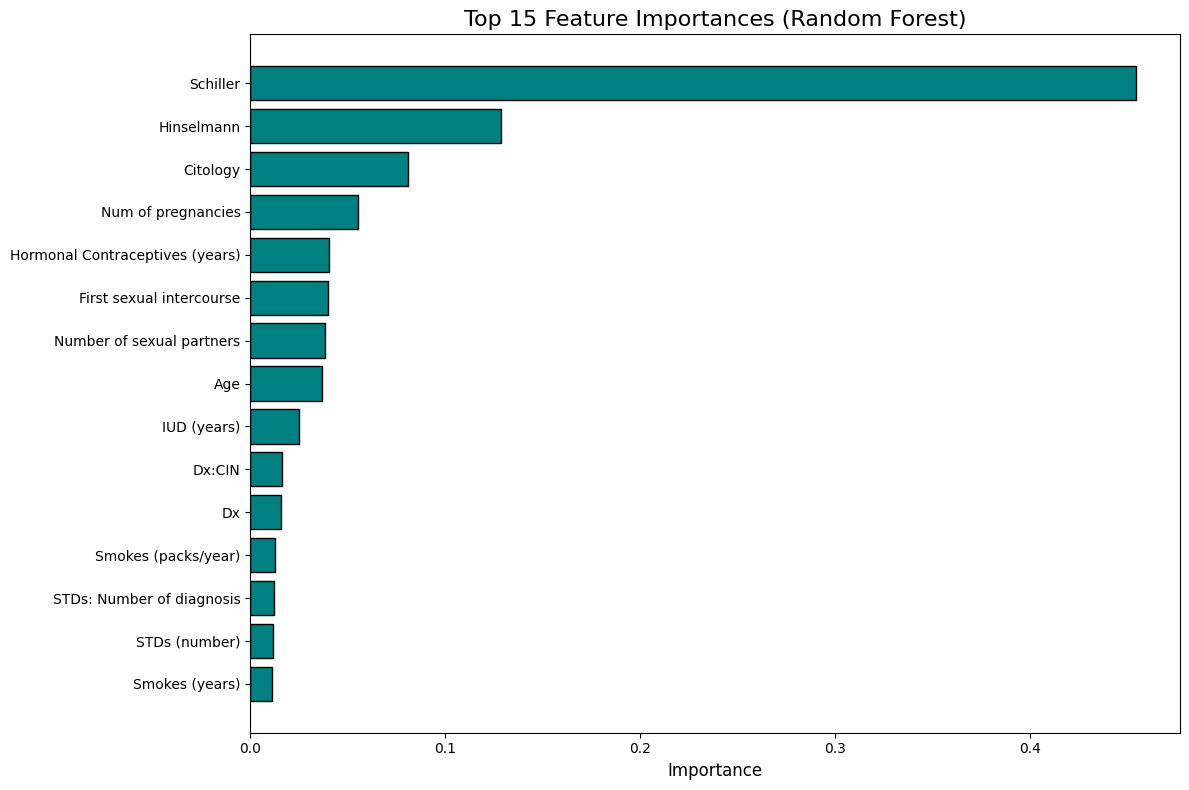


Top 10 Most Important Features:


,Feature,Importance
27,Schiller,0.453963
26,Hinselmann,0.128710
28,Citology,0.080825
3,Num of pregnancies,0.055084
6,Hormonal Contraceptives (years),0.040376
2,First sexual intercourse,0.039733
1,Number of sexual partners,0.038023
0,Age,0.036930
7,IUD (years),0.024695
23,Dx:CIN,0.016438


In [22]:
# Feature importance from Random Forest
feature_importance = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df.head(15)['Feature'][::-1], 
         feature_importance_df.head(15)['Importance'][::-1], 
         color='teal', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=16)
plt.tight_layout()
plt.show()

print('\nTop 10 Most Important Features:')
feature_importance_df.head(10)

## 7. Final Results & Best Model Selection

In [23]:
print('=' * 80)
print('FINAL MODEL EVALUATION SUMMARY')
print('=' * 80)
print()

# Identify best model based on F1-Score (best for imbalanced data)
best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1-Score']
best_acc = results_df.iloc[0]['Accuracy']
best_prec = results_df.iloc[0]['Precision']
best_rec = results_df.iloc[0]['Recall']

print(f'Best Model (by F1-Score): {best_model_name}')
print(f'   Accuracy:  {best_acc:.4f}')
print(f'   Precision: {best_prec:.4f}')
print(f'   Recall:    {best_rec:.4f}')
print(f'   F1-Score:  {best_f1:.4f}')
print()
print('=' * 80)
print()
print('Key Observations:')
print()
print('1. The dataset is highly imbalanced (~5% positive cases for Biopsy).')
print('2. SMOTE was used to balance the training data, improving minority class recall.')
print('3. Ensemble methods (Random Forest, Gradient Boosting, XGBoost) generally')
print('   outperform simple models like Logistic Regression and SVM.')
print('4. F1-Score is the most important metric since we care about both precision')
print('   and recall for cancer detection.')
print('5. ROC-AUC scores indicate the models\' ability to distinguish between classes.')

FINAL MODEL EVALUATION SUMMARY

Best Model (by F1-Score): Linear SVM
   Accuracy:  0.9820
   Precision: 0.8333
   Recall:    0.9091
   F1-Score:  0.8696


Key Observations:

1. The dataset is highly imbalanced (~5% positive cases for Biopsy).
2. SMOTE was used to balance the training data, improving minority class recall.
3. Ensemble methods (Random Forest, Gradient Boosting, XGBoost) generally
   outperform simple models like Logistic Regression and SVM.
4. F1-Score is the most important metric since we care about both precision
   and recall for cancer detection.
5. ROC-AUC scores indicate the models' ability to distinguish between classes.
